# Classification Spam Emails

### Problem Statement
Given a dataset of emails, determine whether each email is "spam" or "not spam."

### Data Colection
- Data source - https://www.kaggle.com/datasets/zubairmustafa/spam-and-ham-classification-balanced-dataset/data from Kanggle
- Data source include 1 file:
+ email.csv

# Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import seaborn as sns
import string
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [2]:
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []       # save history loss
    
    def sigmoid(self, z):
        return 1/(1 + np.exp(-z))
    
    def binary_cross_entropy_loss(self, y_true, y_pred):
        epsilon = 1e-15  # to avoid log(0)
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self, X, y):
        """Training with loss tracking"""
        n_samples, n_features = X.shape 

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        # Gradient descent
        for iteration in range(self.n_iterations):

            # Linear model
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            # Compute loss
            loss = self.binary_cross_entropy_loss(y, y_pred)
            self.loss_history.append(loss)

            # Compute gradients
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Print loss every 100 iterations
            if iteration % 100 == 0:
                print(f"Iteration {iteration}, Loss: {loss:.4f}")
    
    def predict_label(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        return (y_pred >= 0.5).astype(int)
    
    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)
    


# Load data

In [3]:
df = pd.read_csv("email.csv", encoding='latin-1')

In [4]:
df

,label,text
0,ham,into the kingdom of god and those that are ent...
1,spam,there was flow at hpl meter 1505 on april firs...
2,ham,take a look at this one campaign for bvyhprice...
3,spam,somu wrote actually thats what i was looking f...
4,spam,fathi boudra wrote i fixed the issue in the sv...
...,...,...
9984,ham,this would be a great tragedy for all concerne...
9985,ham,"hello , welcome to medzonline filamentous shop..."
9986,ham,this is amazing stuff add some inches fast saf...
9987,spam,author jra date escapenumber escapenumber esca...


In [5]:
df.shape

(9989, 2)

# Data cleaning

In [6]:
# check missing value
df.isna().sum()

label    0
text     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop_duplicates()

,label,text
0,ham,into the kingdom of god and those that are ent...
1,spam,there was flow at hpl meter 1505 on april firs...
2,ham,take a look at this one campaign for bvyhprice...
3,spam,somu wrote actually thats what i was looking f...
4,spam,fathi boudra wrote i fixed the issue in the sv...
...,...,...
9984,ham,this would be a great tragedy for all concerne...
9985,ham,"hello , welcome to medzonline filamentous shop..."
9986,ham,this is amazing stuff add some inches fast saf...
9987,spam,author jra date escapenumber escapenumber esca...


In [9]:
df.shape

(9989, 2)

In [10]:
df.duplicated().sum()

np.int64(0)

# EDA

In [11]:
df.head()

,label,text
0,ham,into the kingdom of god and those that are ent...
1,spam,there was flow at hpl meter 1505 on april firs...
2,ham,take a look at this one campaign for bvyhprice...
3,spam,somu wrote actually thats what i was looking f...
4,spam,fathi boudra wrote i fixed the issue in the sv...


In [12]:
df['label'].value_counts()

label
ham     5294
spam    4695
Name: count, dtype: int64

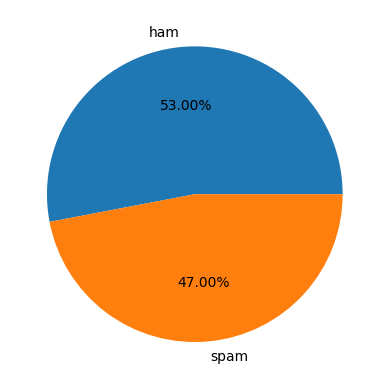

In [13]:
plt.pie(df['label'].value_counts(), labels = ['ham', 'spam'], autopct='%0.2f%%')
plt.show()

In [14]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [15]:
df['num_character']=df['text'].apply(len)
df

,label,text,num_character
0,ham,into the kingdom of god and those that are ent...,1054
1,spam,there was flow at hpl meter 1505 on april firs...,235
2,ham,take a look at this one campaign for bvyhprice...,218
3,spam,somu wrote actually thats what i was looking f...,847
4,spam,fathi boudra wrote i fixed the issue in the sv...,549
...,...,...,...
9984,ham,this would be a great tragedy for all concerne...,1709
9985,ham,"hello , welcome to medzonline filamentous shop...",444
9986,ham,this is amazing stuff add some inches fast saf...,193
9987,spam,author jra date escapenumber escapenumber esca...,1429


In [16]:
df['num_word']=df['text'].apply(lambda x: len(x.split()))

In [17]:
df['num_sentences']=df['text'].apply(lambda x: nltk.sent_tokenize(x)).apply(len)
df

,label,text,num_character,num_word,num_sentences
0,ham,into the kingdom of god and those that are ent...,1054,181,1
1,spam,there was flow at hpl meter 1505 on april firs...,235,56,9
2,ham,take a look at this one campaign for bvyhprice...,218,30,1
3,spam,somu wrote actually thats what i was looking f...,847,160,1
4,spam,fathi boudra wrote i fixed the issue in the sv...,549,83,1
...,...,...,...,...,...
9984,ham,this would be a great tragedy for all concerne...,1709,292,1
9985,ham,"hello , welcome to medzonline filamentous shop...",444,78,3
9986,ham,this is amazing stuff add some inches fast saf...,193,33,1
9987,spam,author jra date escapenumber escapenumber esca...,1429,204,1


In [18]:
df[['num_character', 'num_word', 'num_sentences']].describe()

,num_character,num_word,num_sentences
count,9989.000000,9989.000000,9989.000000
mean,1632.738612,275.213735,7.021123
std,3349.374097,580.162114,26.366359
min,4.000000,1.000000,1.000000
25%,443.000000,78.000000,1.000000
50%,861.000000,149.000000,1.000000
75%,1867.000000,308.000000,5.000000
max,141261.000000,24895.000000,988.000000


In [19]:
df[df['label'] == 'ham'][['num_character', 'num_word', 'num_sentences']].describe()

,num_character,num_word,num_sentences
count,5294.000000,5294.000000,5294.000000
mean,1300.025312,213.998300,6.518700
std,2735.837118,468.852141,20.757494
min,4.000000,1.000000,1.000000
25%,353.000000,59.250000,1.000000
50%,682.500000,117.000000,1.000000
75%,1490.000000,245.000000,4.000000
max,141261.000000,24895.000000,502.000000


In [20]:
df[df['label'] == 'spam'][['num_character', 'num_word', 'num_sentences']].describe()

,num_character,num_word,num_sentences
count,4695.000000,4695.000000,4695.000000
mean,2007.900319,344.239191,7.587646
std,3894.227245,677.741931,31.508210
min,4.000000,1.000000,1.000000
25%,577.000000,107.000000,1.000000
50%,1114.000000,196.000000,1.000000
75%,2160.500000,375.000000,6.000000
max,85490.000000,16876.000000,988.000000


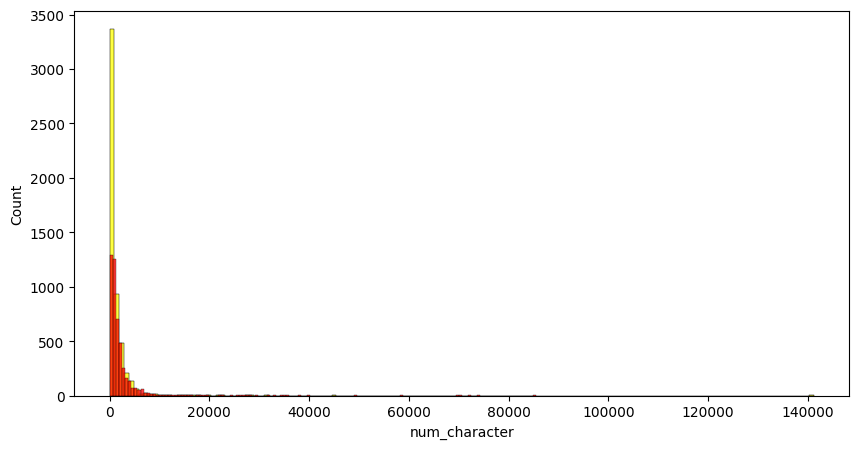

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df[df['label'] == 'ham']['num_character'], color = 'yellow')
sns.histplot(df[df['label'] == 'spam']['num_character'], color = 'red')
plt.show()

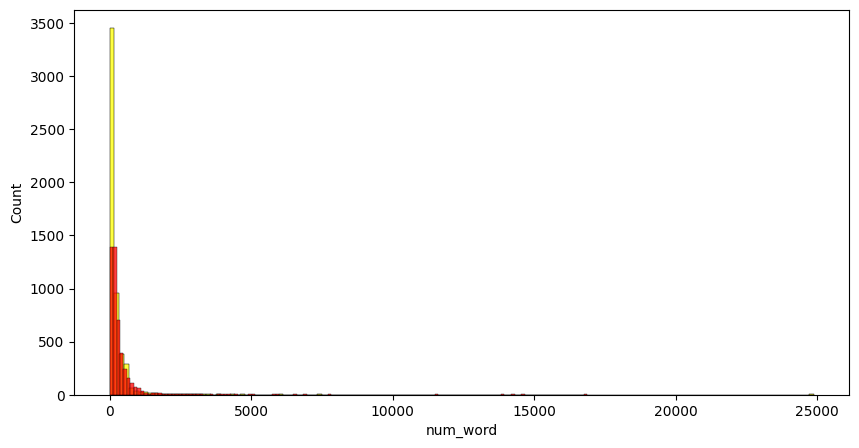

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(df[df['label'] == 'ham']['num_word'], color = 'yellow')
sns.histplot(df[df['label'] == 'spam']['num_word'], color = 'red')
plt.show()

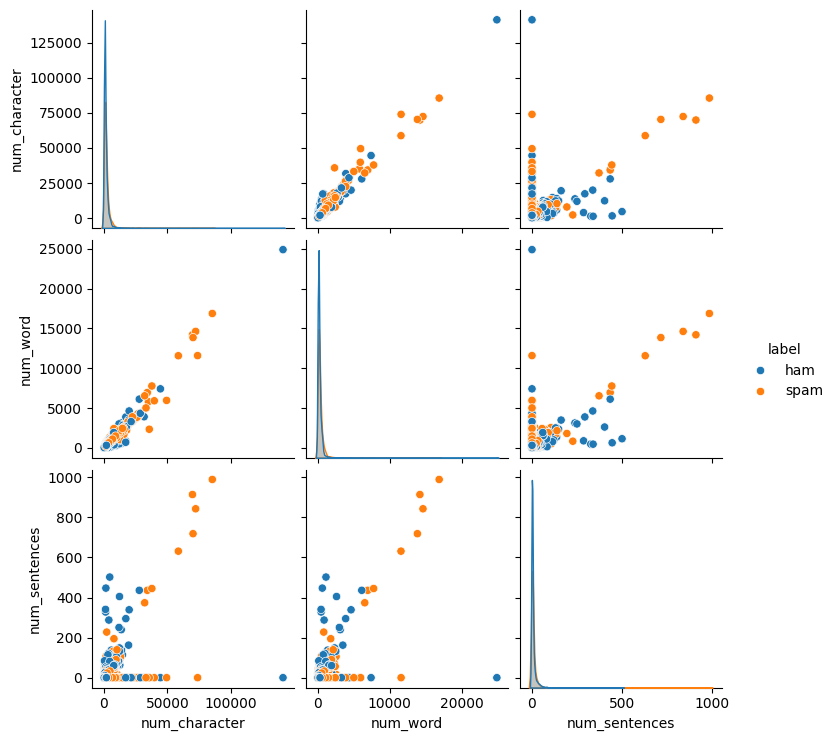

In [23]:
sns.pairplot(df, hue = ('label'))
plt.show()

<Axes: >

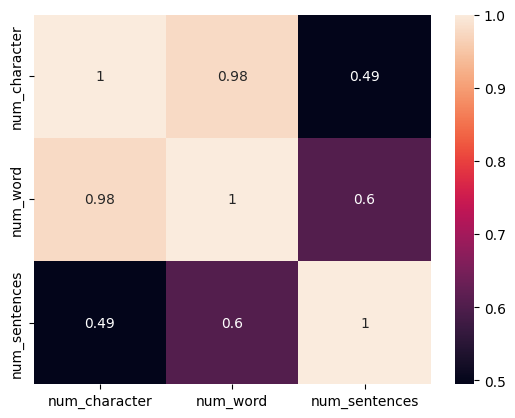

In [24]:
# to see correlation matrix
df_numeric = df.select_dtypes(include=[np.number])
sns.heatmap(df_numeric.corr(), annot = True)

# Data preprocessing
- lower case
- tokenization: split word
- remove special character
- remove stopwords
- steming
# EXPLANATION OF THE TRANSFORM_TEXT FUNCTION:
- This function performs a "text cleaning" pipeline through 5 main steps:
1. Lowercase: Converts the entire text to lowercase to standardize the data.
2. Tokenization: Splits the text string into a list of individual words (tokens).
3. Filter Alphanumeric: Removes special characters and punctuation (@, #, !, ?), keeping only tokens that are alphabetic or numeric.
4. Remove Stopwords & Punctuation: References the NLTK library to filter out common words that lack predictive value (e.g., 'is', 'the', 'are', ...) as well as any remaining punctuation.
5. Stemming: Uses PorterStemmer to strip suffixes, reducing words to their root form (e.g., 'sleeping' -> 'sleep').
Final Result: Returns a single string of the most important pre-processed keywords.

In [25]:
nltk.download('stopwords')
def transform_text(text):
    # lower case
    text = text.lower()

    # split word
    text = nltk.word_tokenize(text)

    # remove special character
    y = []
    for i in text:
        if i.isalnum(): # hold num_word and number
            y.append(i)
    text = y[:]
    y.clear()

    # removve stopwords and punctuation:
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()

    # stemming
    ps = PorterStemmer()
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [26]:
transform_text('hello!!What is Your name?')

'hello name'

In [27]:
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [28]:
df['transform_text']=df['text'].apply(transform_text)
df

,label,text,num_character,num_word,num_sentences,transform_text
0,ham,into the kingdom of god and those that are ent...,1054,181,1,kingdom god enter lord pardon escapenumb us th...
1,spam,there was flow at hpl meter 1505 on april firs...,235,56,9,flow hpl meter 1505 april first deal ticket de...
2,ham,take a look at this one campaign for bvyhprice...,218,30,1,take look one campaign bvyhpric escapenumb esc...
3,spam,somu wrote actually thats what i was looking f...,847,160,1,somu wrote actual that look l r user enter str...
4,spam,fathi boudra wrote i fixed the issue in the sv...,549,83,1,fathi boudra wrote fix issu svn repo rev escap...
...,...,...,...,...,...,...
9984,ham,this would be a great tragedy for all concerne...,1709,292,1,would great tragedi concern situat digit text ...
9985,ham,"hello , welcome to medzonline filamentous shop...",444,78,3,hello welcom medzonlin filament shop pleas int...
9986,ham,this is amazing stuff add some inches fast saf...,193,33,1,amaz stuff add inch fast safe effect seen nbc ...
9987,spam,author jra date escapenumber escapenumber esca...,1429,204,1,author jra date escapenumb escapenumb escapenu...


In [29]:
# word cloud
wc = WordCloud(width = 700, height = 700, min_font_size=10, background_color='yellow')

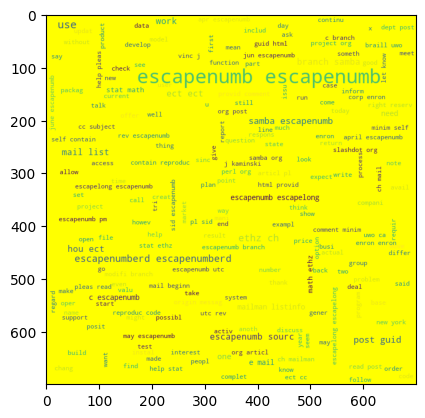

In [30]:
spam_wc = wc.generate(df[df['label'] == 'spam']['transform_text'].str.cat(sep = ' '))
plt.imshow(spam_wc)

In [33]:
len(spam_corpus)

1009778

In [34]:
pd.DataFrame(Counter(spam_corpus).most_common(50))

,0,1
0,escapenumb,91930
1,http,7471
2,r,5882
3,enron,5723
4,org,4987
5,com,4848
6,c,4595
7,ect,4087
8,use,4068
9,help,4024


In [35]:
ham_corpus = []
for msg in df[df['label'] == 'ham']['transform_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [36]:
len(ham_corpus)

675699

In [37]:
pd.DataFrame(Counter(ham_corpus).most_common(50))

,0,1
0,escapenumb,41597
1,escapelong,20974
2,com,4061
3,http,3461
4,per,3331
5,pill,3139
6,price,2992
7,x,2959
8,escapenumbermg,2574
9,compani,2551


# Model building
- Split data and TF-IDF

In [38]:
cv = CountVectorizer()
tfidf = TfidfVectorizer()


In [39]:
X = tfidf.fit_transform(df['transform_text']).toarray()

In [40]:
X.shape

(9989, 72541)

In [41]:
y = df['label'].values

In [42]:
# # Label encoding
y = df['label'].map({'ham': 0, 'spam': 1}).values

In [43]:
y

array([0, 1, 0, ..., 0, 1, 0], shape=(9989,))

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 2
)

# Model training

In [45]:
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X_train, y_train)
y_pred = model.predict_label(X_test)

Iteration 0, Loss: 0.6931
Iteration 100, Loss: 0.6787
Iteration 200, Loss: 0.6667
Iteration 300, Loss: 0.6552
Iteration 400, Loss: 0.6444
Iteration 500, Loss: 0.6340
Iteration 600, Loss: 0.6241
Iteration 700, Loss: 0.6146
Iteration 800, Loss: 0.6056
Iteration 900, Loss: 0.5969


# Evaluation model

Accuracy: 0.8118
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.97      0.84      1049
           1       0.95      0.64      0.76       949

    accuracy                           0.81      1998
   macro avg       0.85      0.80      0.80      1998
weighted avg       0.84      0.81      0.81      1998



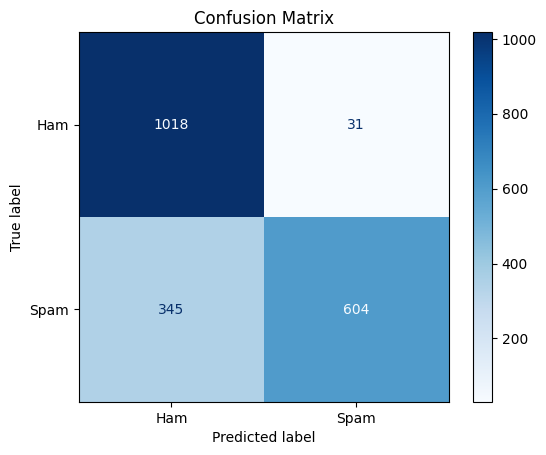

In [46]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()